<a href="https://colab.research.google.com/github/mmbc560/GUIA2/blob/main/Simulaci%C3%B3n2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RESUMEN DEL MODELO DE CALIDAD LOGÍSTICA
---------------------------------------
Calidad promedio final: 95.49 %
Calidad mínima: 72.44 %
Calidad máxima: 100.0 %
Probabilidad de calidad menor al 75%: 0.04 %
Probabilidad de incumplir plazo de 30 días: 10.82 %


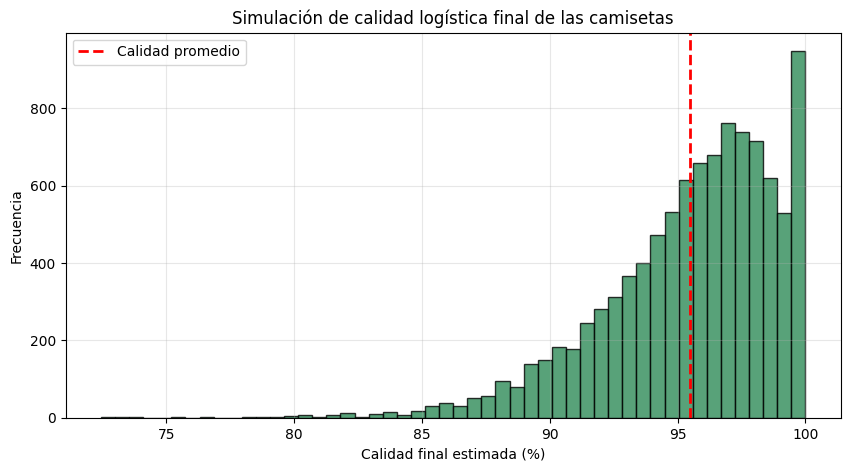


Interpretación:
Esta gráfica muestra qué porcentaje de calidad comercial podrían conservar las camisetas
después del proceso logístico internacional. Si la mayoría de escenarios se ubica por encima
del 90%, el proceso es confiable. Si aparecen muchos casos por debajo del 75%, se deben revisar
empaque, tiempos de tránsito, humedad y manipulación.


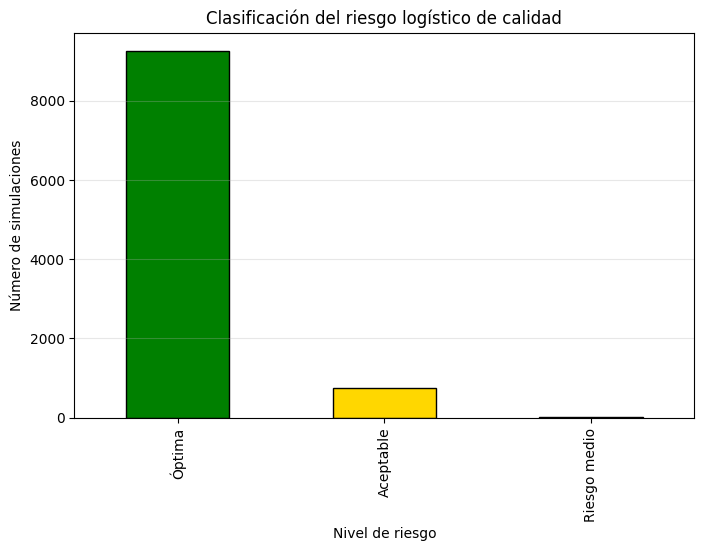


Interpretación:
Esta gráfica permite concluir si el plan exportador protege adecuadamente la calidad del producto.
Para camisetas, la calidad depende especialmente del estado del empaque, la humedad, el manejo
y el cumplimiento del tiempo pactado. Si predominan los escenarios verdes y amarillos,
la operación logística puede considerarse adecuada.


In [1]:
# ============================================================
# MODELO PREDICTIVO DE PÉRDIDA DE CALIDAD LOGÍSTICA
# Caso: exportación de camisetas a Frankfurt
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. DATOS BASE DEL CASO
# ============================================================
# Estos datos deben ajustarse según el producto de cada grupo.

simulaciones = 10000

cantidad_camisetas = 10000
tiempo_maximo_entrega = 30     # días máximos pactados con el cliente
calidad_inicial = 100          # calidad comercial inicial en %

# ============================================================
# 2. VARIABLES LOGÍSTICAS CON INCERTIDUMBRE
# ============================================================
# Para camisetas, los riesgos no son de maduración,
# sino de humedad, retrasos, manipulación y empaque.

tiempo_transito = np.random.normal(25, 4, simulaciones)
humedad = np.random.normal(60, 10, simulaciones)
manipulacion = np.random.normal(3, 1, simulaciones)
estado_empaque = np.random.normal(95, 5, simulaciones)

# Evitar valores incoherentes
tiempo_transito = np.maximum(tiempo_transito, 1)
humedad = np.clip(humedad, 0, 100)
manipulacion = np.clip(manipulacion, 1, 5)
estado_empaque = np.clip(estado_empaque, 0, 100)

# ============================================================
# 3. CÁLCULO DE PÉRDIDA DE CALIDAD
# ============================================================
# La calidad disminuye por:
# - retrasos frente al plazo pactado
# - humedad alta
# - manipulación deficiente
# - deterioro del empaque

perdida_por_retraso = np.maximum(tiempo_transito - tiempo_maximo_entrega, 0) * 2

perdida_por_humedad = np.maximum(humedad - 70, 0) * 0.5

perdida_por_manipulacion = np.maximum(manipulacion - 3, 0) * 4

perdida_por_empaque = np.maximum(100 - estado_empaque, 0) * 0.4

perdida_total = (
    perdida_por_retraso +
    perdida_por_humedad +
    perdida_por_manipulacion +
    perdida_por_empaque
)

calidad_final = calidad_inicial - perdida_total
calidad_final = np.clip(calidad_final, 0, 100)

# ============================================================
# 4. CLASIFICACIÓN DEL RIESGO
# ============================================================

def clasificar_calidad(calidad):
    if calidad >= 90:
        return "Óptima"
    elif calidad >= 75:
        return "Aceptable"
    elif calidad >= 60:
        return "Riesgo medio"
    else:
        return "Riesgo alto"

riesgo = [clasificar_calidad(c) for c in calidad_final]

resultados = pd.DataFrame({
    "Tiempo tránsito": tiempo_transito,
    "Humedad": humedad,
    "Manipulación": manipulacion,
    "Estado empaque": estado_empaque,
    "Calidad final": calidad_final,
    "Riesgo": riesgo
})

# ============================================================
# 5. RESULTADOS GENERALES
# ============================================================

print("RESUMEN DEL MODELO DE CALIDAD LOGÍSTICA")
print("---------------------------------------")
print("Calidad promedio final:", round(resultados["Calidad final"].mean(), 2), "%")
print("Calidad mínima:", round(resultados["Calidad final"].min(), 2), "%")
print("Calidad máxima:", round(resultados["Calidad final"].max(), 2), "%")
print("Probabilidad de calidad menor al 75%:",
      round((resultados["Calidad final"] < 75).mean() * 100, 2), "%")
print("Probabilidad de incumplir plazo de 30 días:",
      round((resultados["Tiempo tránsito"] > 30).mean() * 100, 2), "%")

# ============================================================
# 6. GRÁFICA DE CALIDAD FINAL
# ============================================================

plt.figure(figsize=(10,5))
plt.hist(resultados["Calidad final"], bins=50, color="seagreen", edgecolor="black", alpha=0.8)
plt.axvline(resultados["Calidad final"].mean(), color="red", linestyle="--", linewidth=2, label="Calidad promedio")
plt.title("Simulación de calidad logística final de las camisetas")
plt.xlabel("Calidad final estimada (%)")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nInterpretación:")
print("Esta gráfica muestra qué porcentaje de calidad comercial podrían conservar las camisetas")
print("después del proceso logístico internacional. Si la mayoría de escenarios se ubica por encima")
print("del 90%, el proceso es confiable. Si aparecen muchos casos por debajo del 75%, se deben revisar")
print("empaque, tiempos de tránsito, humedad y manipulación.")

# ============================================================
# 7. GRÁFICA DE CLASIFICACIÓN DE RIESGO
# ============================================================

conteo_riesgo = resultados["Riesgo"].value_counts()

colores = {
    "Óptima": "green",
    "Aceptable": "gold",
    "Riesgo medio": "orange",
    "Riesgo alto": "red"
}

plt.figure(figsize=(8,5))
conteo_riesgo.plot(
    kind="bar",
    color=[colores[x] for x in conteo_riesgo.index],
    edgecolor="black"
)
plt.title("Clasificación del riesgo logístico de calidad")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Número de simulaciones")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("\nInterpretación:")
print("Esta gráfica permite concluir si el plan exportador protege adecuadamente la calidad del producto.")
print("Para camisetas, la calidad depende especialmente del estado del empaque, la humedad, el manejo")
print("y el cumplimiento del tiempo pactado. Si predominan los escenarios verdes y amarillos,")
print("la operación logística puede considerarse adecuada.")